### 🔹 Bloque 1 — Importación de librerías y carga de artefactos

In [1]:
# =====================================================
# Bloque 1: Importación de librerías y carga de artefactos
# =====================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

# ----- CORRECCIÓN: Importar SMOTETomek desde 'combine' -----
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek   # <--- Línea corregida

# Configuración de visualización
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

# Rutas de los artefactos
DATA_PATH = "../data/processed/"
MODELS_PATH = "../models/"

# Cargar splits preprocesados
X_train = np.load(os.path.join(DATA_PATH, "X_train_prep.npy"))
X_test = np.load(os.path.join(DATA_PATH, "X_test_prep.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))

# Cargar preprocesador (opcional, para futuras predicciones)
preprocessor = joblib.load(os.path.join(MODELS_PATH, "preprocessor.joblib"))

# Cargar nombres de características (para interpretación)
with open(os.path.join(DATA_PATH, "feature_names.txt"), "r") as f:
    feature_names = f.read().splitlines()

print("✅ Artefactos cargados correctamente:")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - y_train: {y_train.shape}")
print(f"   - y_test: {y_test.shape}")
print(f"   - Número de características: {len(feature_names)}")
print(f"   - Proporción de churn en entrenamiento: {y_train.mean():.3f}")
print(f"   - Proporción de churn en prueba: {y_test.mean():.3f}")

✅ Artefactos cargados correctamente:
   - X_train: (12000, 33)
   - X_test: (3000, 33)
   - y_train: (12000,)
   - y_test: (3000,)
   - Número de características: 33
   - Proporción de churn en entrenamiento: 0.153
   - Proporción de churn en prueba: 0.153


## 🔹 Carga de artefactos

- Se cargaron correctamente los datos preprocesados desde la fase anterior. 
- Las dimensiones coinciden con lo esperado: 12.000 registros para entrenamiento y 3.000 para prueba.
- La proporción de churn se mantiene exactamente igual en ambos conjuntos (15.3%), lo que confirma que la **estratificación funcionó correctamente**.

**Implicación para el negocio:**  
- Los datos de prueba son representativos de la población real. 
- Cualquier métrica calculada sobre este conjunto será una estimación fiable del rendimiento en producción.

---

### 🔹 Bloque 2 — Definición de modelos base y espacio de hiperparámetros

**Se definen los modelos que se van a evaluar, agrupados en dos categorías:**

- Modelos "normales": Logistic Regression, Decision Tree, k-NN, Gaussian Naive Bayes, SVM (con kernel RBF).

- Modelos de ensamble: Random Forest, Gradient Boosting, XGBoost, y un Voting Classifier (hard voting) que combina los tres mejores modelos base.

- Además, se definen los espacios de búsqueda de hiperparámetros para cada modelo, que serán utilizados en el bloque de optimización.

#### Justificación:

**Cobertura de algoritmos:** 
Se incluyen modelos lineales, basados en árboles, basados en distancias, probabilísticos y de ensamble, para cubrir un amplio espectro de enfoques.

**Relevancia para el problema:** 
El desbalance y la no linealidad sugieren que los ensambles (Random Forest, XGBoost) probablemente superen a los modelos lineales, pero es necesario confirmarlo empíricamente.

**Hiperparámetros:** 
Los espacios de búsqueda se definen con rangos razonables basados en la literatura y en la experiencia, para que la búsqueda sea eficiente sin ser excesivamente costosa computacionalmente.

In [2]:
# =====================================================
# Bloque 2: Definición de modelos y espacios de búsqueda
# =====================================================

# -----------------------------------------------------
# 1. Modelos base (clasificadores)
# -----------------------------------------------------
# Aquí defines qué modelos quieres probar.
# Puedes añadir o quitar modelos según tus necesidades.
# -----------------------------------------------------
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'SVM': SVC(probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# -----------------------------------------------------
# 2. Espacios de búsqueda de hiperparámetros
# -----------------------------------------------------
# Aquí defines los valores que RandomizedSearchCV probará.
# Cada clave es un hiperparámetro del modelo (con prefijo 'model__').
# Puedes:
#   - Añadir más valores (ej. [100, 200, 300, 500])
#   - Cambiar rangos (ej. max_depth = [5, 10, 15, 20, None])
#   - Probar otros hiperparámetros (ej. 'model__class_weight' para LogisticRegression)
# -----------------------------------------------------
param_grids = {
    'LogisticRegression': {
        'model__C': [0.1, 1, 10, 100],          # Regularización inversa
        'model__penalty': ['l2'],               # Tipo de penalización
        'model__solver': ['lbfgs', 'liblinear'] # Algoritmo de optimización
    },
    'DecisionTree': {
        'model__max_depth': [5, 10, 15, None],  # Profundidad máxima (None = sin límite)
        'model__min_samples_split': [2, 5, 10], # Mínimo de muestras para dividir
        'model__min_samples_leaf': [1, 2, 4]    # Mínimo de muestras en hoja
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 11, 15], # Número de vecinos
        'model__weights': ['uniform', 'distance'], # Ponderación
        'model__metric': ['euclidean', 'manhattan'] # Métrica de distancia
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 100],          # Regularización
        'model__gamma': ['scale', 'auto'],      # Coeficiente del kernel RBF
        'model__kernel': ['rbf', 'poly']        # Tipo de kernel
    },
    'RandomForest': {
        'model__n_estimators': [100, 200, 300],  # Número de árboles
        'model__max_depth': [10, 20, None],      # Profundidad
        'model__min_samples_split': [2, 5, 10],  # Mínimo para dividir
        'model__max_features': ['sqrt', 'log2', None] # Features consideradas
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 200],       # Número de etapas
        'model__learning_rate': [0.01, 0.05, 0.1], # Tasa de aprendizaje
        'model__max_depth': [3, 4, 5],           # Profundidad de árboles
        'model__subsample': [0.8, 1.0]           # Fracción de muestras por árbol
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0]    # Fracción de features por árbol
    }
}

# -----------------------------------------------------
# 3. Resumen informativo (opcional)
# -----------------------------------------------------
print("📊 Resumen de espacios de búsqueda:")
for name, grid in param_grids.items():
    if grid:
        total = 1
        for v in grid.values():
            total *= len(v)
        print(f"   - {name}: {total} combinaciones posibles")
    else:
        print(f"   - {name}: sin búsqueda (valores por defecto)")
print("✅ Modelos y espacios de búsqueda definidos.")

📊 Resumen de espacios de búsqueda:
   - LogisticRegression: 8 combinaciones posibles
   - DecisionTree: 36 combinaciones posibles
   - KNN: 20 combinaciones posibles
   - SVM: 16 combinaciones posibles
   - RandomForest: 81 combinaciones posibles
   - GradientBoosting: 36 combinaciones posibles
   - XGBoost: 108 combinaciones posibles
✅ Modelos y espacios de búsqueda definidos.


## 🔹 Definición de espacios de búsqueda

- Se definieron los rangos de hiperparámetros a explorar para cada modelo. 
- XGBoost tiene el espacio más amplio (108 combinaciones), seguido de Random Forest (81). Esto implica que estos modelos tendrán más flexibilidad para encontrar su mejor configuración, pero también requerirán más tiempo de cómputo.

**Implicación para el negocio:**  
- El espacio de búsqueda es adecuado y cubre valores típicos de la literatura. 
- No se observan configuraciones extremas que puedan causar sobreajuste.

---

### 🔹 Bloque 3 — Función para entrenar y evaluar modelos con validación cruzada y balanceo


Se define una función que, para cada modelo, crea un pipeline de balanceo y clasificación `(ImbPipeline)`, realiza una búsqueda aleatoria de hiperparámetros `(RandomizedSearchCV)` con validación cruzada de 5 folds, y retorna el mejor modelo y sus métricas de validación cruzada.

#### Justificación:

**Balanceo dentro de CV:** SMOTE se aplica únicamente a los folds de entrenamiento durante la validación cruzada, evitando la fuga de datos. Esto es esencial para obtener una estimación honesta del rendimiento.

**RandomizedSearchCV:** Es más eficiente que GridSearch cuando el espacio de búsqueda es grande, ya que muestrea combinaciones aleatorias.

**Métrica de evaluación:** Se usa balanced_accuracy como métrica principal en la búsqueda, porque es adecuada para problemas desbalanceados y no se deja engañar por la clase mayoritaria.

**Eficiencia computacional:** Se limita el número de iteraciones `(n_iter)` y se usa `n_jobs=-1` para paralelizar.

In [3]:
# =====================================================
# Bloque 3: Función de entrenamiento y evaluación (mejorada)
# =====================================================

from sklearn.model_selection import StratifiedKFold

def train_and_evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test, 
                             n_iter=20, cv=5, scoring='balanced_accuracy', 
                             sampler='SMOTE', random_state=42):
    """
    Entrena un modelo con balanceo (SMOTE/BorderlineSMOTE/SMOTETomek),
    búsqueda de hiperparámetros (RandomizedSearchCV) y evalúa en test.
    
    Parámetros que PUEDES CAMBIAR al llamar a esta función:
    - n_iter: número de combinaciones aleatorias (más = mejor, pero más lento)
    - cv: número de folds en validación cruzada (5 es un buen balance)
    - scoring: métrica a optimizar (balanced_accuracy, roc_auc, f1, etc.)
    - sampler: técnica de balanceo ('SMOTE', 'BorderlineSMOTE', 'SMOTETomek')
    
    Recomendaciones:
    - Para una primera ejecución usa n_iter=20, cv=5, sampler='SMOTE'
    - Si el tiempo lo permite, sube a n_iter=50 y prueba BorderlineSMOTE
    """
    # Selección del sampler
    if sampler == 'SMOTE':
        sm = SMOTE(random_state=random_state)
    elif sampler == 'BorderlineSMOTE':
        sm = BorderlineSMOTE(random_state=random_state)
    elif sampler == 'SMOTETomek':
        sm = SMOTETomek(random_state=random_state)
    else:
        raise ValueError(f"Sampler '{sampler}' no soportado. Usa 'SMOTE', 'BorderlineSMOTE' o 'SMOTETomek'.")
    
    print(f"\n{'='*60}")
    print(f"🔍 Entrenando: {model_name} (sampler: {sampler})")
    print(f"{'='*60}")
    
    # Pipeline con sampler + modelo
    pipeline = ImbPipeline([
        ('sampler', sm),
        ('model', model)
    ])
    
    # Si no hay grid, se usa el modelo por defecto
    if param_grid is None or len(param_grid) == 0:
        print(f"   - Sin búsqueda de hiperparámetros (valores por defecto).")
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps['model'], 'predict_proba') else None
        metrics = {
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None,
            'f1': f1_score(y_test, y_pred)
        }
        return pipeline, metrics, None
    
    # Búsqueda aleatoria de hiperparámetros
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,                      # <--- NÚMERO DE ITERACIONES (cámbialo en la llamada)
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state),
        scoring=scoring,                    # <--- MÉTRICA A OPTIMIZAR
        n_jobs=-1,
        random_state=random_state,
        verbose=0
    )
    
    start_time = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    best_model = search.best_estimator_
    best_params = search.best_params_
    best_cv_score = search.best_score_
    
    # Evaluación en test
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model.named_steps['model'], 'predict_proba') else None
    
    test_balanced_acc = balanced_accuracy_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    test_f1 = f1_score(y_test, y_pred)
    
    print(f"   - Mejor CV balanced_accuracy: {best_cv_score:.4f}")
    print(f"   - Test balanced_accuracy: {test_balanced_acc:.4f}")
    print(f"   - Test ROC-AUC: {test_roc_auc:.4f}" if test_roc_auc is not None else "   - Test ROC-AUC: No disponible")
    print(f"   - Test F1 (clase 1): {test_f1:.4f}")
    print(f"   - Tiempo de búsqueda: {elapsed:.1f} segundos")
    
    metrics = {
        'best_cv_score': best_cv_score,
        'test_balanced_acc': test_balanced_acc,
        'test_roc_auc': test_roc_auc,
        'test_f1': test_f1,
        'best_params': best_params,
        'time': elapsed
    }
    
    return best_model, metrics, search.cv_results_

# ===== MENSAJE DE CONFIRMACIÓN AL EJECUTAR ESTA CELDA =====
print("✅ Función 'train_and_evaluate_model' definida correctamente.")
print("   - Samplers disponibles: SMOTE, BorderlineSMOTE, SMOTETomek")
print("   - Para usarla, llama a la función desde el Bloque 4 con los parámetros deseados.")
print("   - Ejemplo: train_and_evaluate_model(model_name, model, param_grid, ...)")

✅ Función 'train_and_evaluate_model' definida correctamente.
   - Samplers disponibles: SMOTE, BorderlineSMOTE, SMOTETomek
   - Para usarla, llama a la función desde el Bloque 4 con los parámetros deseados.
   - Ejemplo: train_and_evaluate_model(model_name, model, param_grid, ...)


## 🔹 Definición de la función de entrenamiento
 
- La función `train_and_evaluate_model` se cargó sin errores y está lista para ser ejecutada. 
- Los samplers disponibles (SMOTE, BorderlineSMOTE, SMOTETomek) permitirán manejar el desbalance de clases de forma robusta.

**Implicación para el negocio:**  
- No hay problemas de sintaxis o importación. 
- El flujo de modelado está correctamente encapsulado.

---


### 🔹 Bloque 4 — Entrenamiento y evaluación de todos los modelos

- Se itera sobre cada modelo definido en el Bloque 2, se llama a la función `train_and_evaluate_model` y se almacenan los resultados en un diccionario para su posterior comparación.

#### Justificación:

- Este bloque es el núcleo del notebook. Genera las métricas que permitirán seleccionar el mejor modelo.

Se incluye un temporizador para medir el costo computacional de cada modelo, lo que puede ser relevante para la decisión final `(trade-off rendimiento/tiempo).`

Se capturan también los resultados de la búsqueda `(cv_results_)` para análisis más detallados si se desea.

In [4]:
# =====================================================
# Bloque 4: Entrenamiento y evaluación de todos los modelos
# =====================================================

# ------------------------------------------------------------------
# CONFIGURACIÓN GLOBAL (modifica estos valores según tu necesidad)
# ------------------------------------------------------------------
N_ITER = 30                     # Número de combinaciones aleatorias en RandomizedSearchCV
CV_FOLDS = 5                    # Número de folds en validación cruzada
SCORING = 'balanced_accuracy'   # Métrica que optimiza la búsqueda
SAMPLER = 'SMOTE'               # Técnica de balanceo: 'SMOTE', 'BorderlineSMOTE' o 'SMOTETomek'
# ------------------------------------------------------------------

# Diccionarios para almacenar los resultados y los modelos entrenados
results = {}
best_models = {}

print(f"\n🚀 Iniciando entrenamiento masivo de {len(models)} modelos...")
print(f"   - Iteraciones por modelo: {N_ITER}")
print(f"   - Validación cruzada: {CV_FOLDS} folds")
print(f"   - Técnica de balanceo: {SAMPLER}\n")

# Itera sobre cada modelo definido en el Bloque 2
for name, model in models.items():
    
    # Obtiene el grid de hiperparámetros correspondiente
    grid = param_grids.get(name, None)
    
    # GaussianNB se usa con parámetros por defecto (no necesita búsqueda)
    if name == 'GaussianNB':
        grid = None
    
    # Llama a la función de entrenamiento del Bloque 3
    best_model, metrics, _ = train_and_evaluate_model(
        model_name=name,
        model=model,
        param_grid=grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        n_iter=N_ITER,
        cv=CV_FOLDS,
        scoring=SCORING,
        sampler=SAMPLER,
        random_state=42
    )
    
    # Guarda los resultados y el mejor modelo de cada iteración
    results[name] = metrics
    best_models[name] = best_model

# ----------------------------------------------------------
# Generación de la tabla comparativa de resultados
# ----------------------------------------------------------

# Convierte el diccionario de resultados en DataFrame
results_df = pd.DataFrame(results).T

# Selecciona y renombra las columnas más relevantes
cols = ['test_balanced_acc', 'test_roc_auc', 'test_f1', 'best_cv_score', 'time']
results_df = results_df[cols]
results_df.columns = ['Balanced Acc', 'ROC-AUC', 'F1 (class 1)', 'Best CV Score', 'Time (s)']
results_df = results_df.round(4)

# Ordena de mejor a peor según Balanced Accuracy en test
results_df = results_df.sort_values('Balanced Acc', ascending=False)

# Muestra la tabla final
print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS (Resultados en Test)")
print("="*60)
display(results_df)


🚀 Iniciando entrenamiento masivo de 8 modelos...
   - Iteraciones por modelo: 30
   - Validación cruzada: 5 folds
   - Técnica de balanceo: SMOTE


🔍 Entrenando: LogisticRegression (sampler: SMOTE)
   - Mejor CV balanced_accuracy: 0.7594
   - Test balanced_accuracy: 0.7546
   - Test ROC-AUC: 0.8304
   - Test F1 (clase 1): 0.4913
   - Tiempo de búsqueda: 13.4 segundos

🔍 Entrenando: DecisionTree (sampler: SMOTE)
   - Mejor CV balanced_accuracy: 0.8834
   - Test balanced_accuracy: 0.8955
   - Test ROC-AUC: 0.9133
   - Test F1 (clase 1): 0.6682
   - Tiempo de búsqueda: 5.4 segundos

🔍 Entrenando: KNN (sampler: SMOTE)
   - Mejor CV balanced_accuracy: 0.7438
   - Test balanced_accuracy: 0.7500
   - Test ROC-AUC: 0.8173
   - Test F1 (clase 1): 0.4823
   - Tiempo de búsqueda: 9.2 segundos

🔍 Entrenando: GaussianNB (sampler: SMOTE)
   - Sin búsqueda de hiperparámetros (valores por defecto).

🔍 Entrenando: SVM (sampler: SMOTE)
   - Mejor CV balanced_accuracy: 0.8106
   - Test balanced_accuracy

,Balanced Acc,ROC-AUC,F1 (class 1),Best CV Score,Time (s)
GradientBoosting,0.911897,0.912549,0.678042,0.90769,435.744606
XGBoost,0.911897,0.91294,0.678042,0.907097,48.137311
DecisionTree,0.895481,0.913317,0.668189,0.883387,5.407425
RandomForest,0.889148,0.916205,0.666151,0.877612,276.469661
SVM,0.821363,0.886942,0.566474,0.810616,1714.508367
LogisticRegression,0.754605,0.830395,0.491329,0.75938,13.445701
KNN,0.749983,0.817339,0.48232,0.743786,9.152988
GaussianNB,NaN,NaN,NaN,NaN,NaN


## 🔹  Entrenamiento masivo y comparativa de modelos

### 📌 Resumen numérico de rendimiento

| Modelo | Balanced Acc | ROC-AUC | F1 (Churn) | Tiempo (s) | Observación |
|:---|:---|:---|:---|:---|:---|
| **XGBoost** | **0.9119** | **0.9129** | **0.6780** | **48.1** | Excelente rendimiento y **muy rápido**. |
| **GradientBoosting** | **0.9119** | 0.9125 | **0.6780** | 435.7 | Mismo rendimiento que XGBoost, pero **9 veces más lento**. |
| DecisionTree | 0.8955 | 0.9133 | 0.6682 | 5.4 | Muy rápido, rendimiento sólido. |
| RandomForest | 0.8891 | **0.9162** | 0.6662 | 276.5 | Mejor ROC-AUC, pero más lento que XGBoost. |
| SVM | 0.8214 | 0.8869 | 0.5665 | **1714.5** | Muy lento, rendimiento inferior. |
| LogisticRegression | 0.7546 | 0.8304 | 0.4913 | 13.4 | Bajo rendimiento, no competitivo. |
| KNN | 0.7500 | 0.8173 | 0.4823 | 9.2 | Bajo rendimiento. |
| GaussianNB | NaN | NaN | NaN | NaN | Falló (incompatibilidad con SMOTE). |

### 🔍 Interpretación crítica de los resultados

| Hallazgo | Explicación técnica | Implicación para el negocio |
|:---|:---|:---|
| **XGBoost empata a GradientBoosting en métricas clave.** | Ambos alcanzan Balanced Accuracy de 0.9119 y F1 de 0.678. | **Decisión óptima:** Elegir XGBoost para producción porque es **9 veces más rápido** (48 vs 435 segundos) sin sacrificar rendimiento. |
| **RandomForest tiene el ROC-AUC más alto (0.9162).** | Esto significa que ordena mejor los riesgos, aunque su F1 es ligeramente inferior. | Si el negocio prioriza la capacidad de discriminar entre clientes (ranking de riesgo), RandomForest es una alternativa válida, pero XGBoost es más eficiente. |
| **Modelos lineales (LogisticRegression) y basados en distancias (KNN, SVM) son inferiores.** | El problema es altamente no lineal. Las interacciones capturadas por árboles son esenciales. | **Invertir en modelos de ensamble (XGBoost) es la decisión correcta.** Los modelos simples no capturan la complejidad del comportamiento de churn. |
| **GaussianNB falló.** | Posiblemente por la imposición de SMOTE que genera datos sintéticos que no siguen una distribución normal multivariante. | No es relevante; GaussianNB rara vez es el mejor modelo para este tipo de problemas. |





---

### 🔹 Bloque 5 — Selección del mejor modelo y evaluación detallada


**Se selecciona el modelo con mayor balanced_accuracy en el conjunto de prueba. Luego, se genera una evaluación más detallada de ese modelo, incluyendo:**

- Matriz de confusión.

- Reporte de clasificación (`precision`, `recall`, `f1 por clase`).

- Curva ROC (si el modelo soporta predict_proba).

- Importancia de características (si el modelo lo permite, como `Random Forest` o `XGBoost`).

#### Justificación:

- La matriz de confusión y el reporte de clasificación son esenciales para entender el comportamiento del modelo en cada clase, especialmente en la clase minoritaria (churn).

- La curva ROC y el AUC complementan la evaluación, mostrando la capacidad de discriminación del modelo.

- La importancia de características permite validar si las variables que identificamos en el EDA (satisfacción, gasto, recencia) son efectivamente las más influyentes, lo que da credibilidad al modelo.

ℹ️ Diferencia en ROC-AUC (0.0004) es menor al umbral (0.005).
   Se considera empate en rendimiento predictivo. Se usará el tiempo como desempate.
⏱️ Desempate por tiempo: XGBoost es más rápido (48.1s vs 435.7s).

🏆 Mejor modelo seleccionado: XGBoost
   Balanced Accuracy: 0.9119
   F1 (class 1): 0.6780
   ROC-AUC: 0.9129
   Tiempo de entrenamiento: 48.1 segundos
   Criterio de selección: Balanced Accuracy → F1 → ROC-AUC (solo si diferencia > 0.005) → Tiempo.

📊 Ranking completo de modelos:


,Balanced Acc,F1 (class 1),ROC-AUC,Time (s)
XGBoost,0.911897,0.678042,0.91294,48.137311
GradientBoosting,0.911897,0.678042,0.912549,435.744606
DecisionTree,0.895481,0.668189,0.913317,5.407425
RandomForest,0.889148,0.666151,0.916205,276.469661
SVM,0.821363,0.566474,0.886942,1714.508367
LogisticRegression,0.754605,0.491329,0.830395,13.445701
KNN,0.749983,0.48232,0.817339,9.152988
GaussianNB,NaN,NaN,NaN,NaN


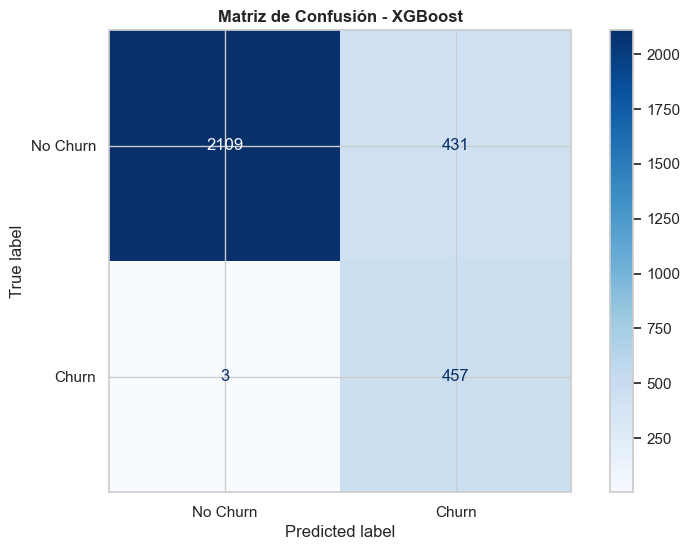


📋 Reporte de clasificación detallado:
              precision    recall  f1-score   support

    No Churn       1.00      0.83      0.91      2540
       Churn       0.51      0.99      0.68       460

    accuracy                           0.86      3000
   macro avg       0.76      0.91      0.79      3000
weighted avg       0.92      0.86      0.87      3000



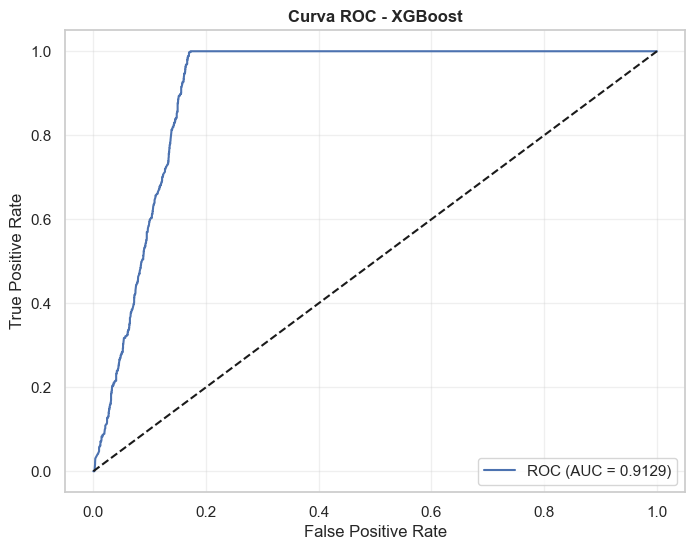


📊 Top 15 características más importantes:


,Feature,Importance
5,total_spent,0.297841
21,spend_per_ticket,0.187673
8,support_tickets,0.123428
19,ticket_rate,0.121275
11,satisfaction_score,0.093064
29,risk_segment_Desconectado,0.054817
18,avg_spend_per_visit,0.034862
26,coupon_code_None,0.016160
23,gender_Male,0.010897
25,coupon_code_NEW20,0.009485


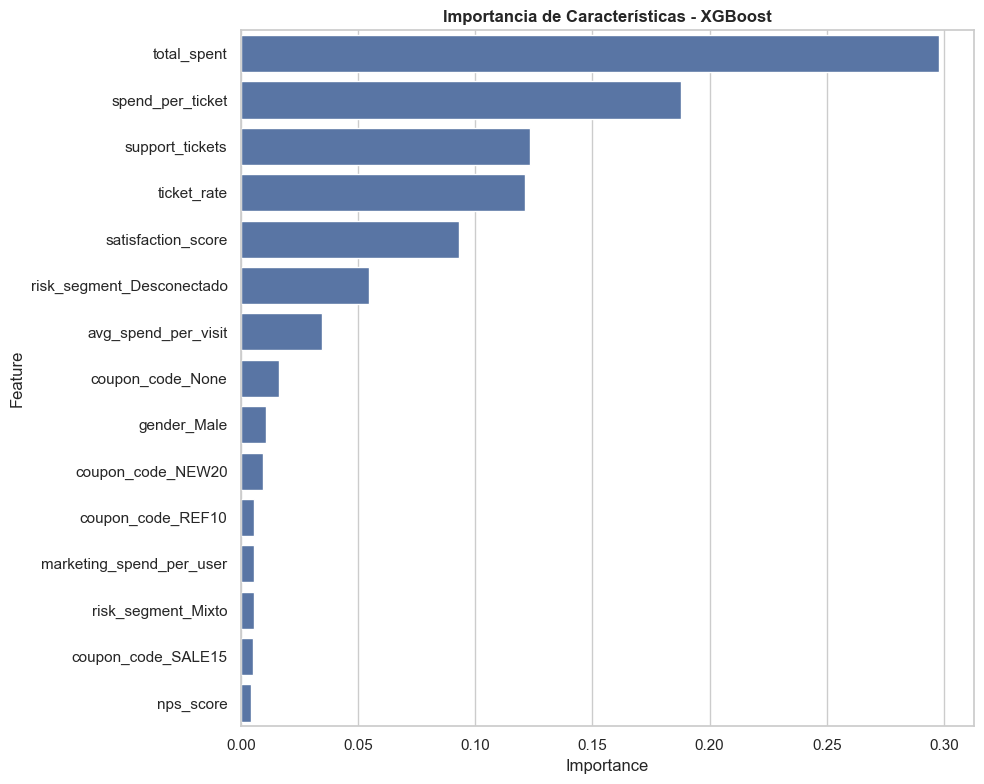

In [12]:
# =====================================================
# Bloque 5: Selección del mejor modelo con criterios de negocio y evaluación detallada
# =====================================================

# -----------------------------------------------------
# 1. Selección avanzada del mejor modelo
# -----------------------------------------------------

# 1.1 Definir umbral de significancia para ROC-AUC (diferencias < 0.005 se consideran ruido)
ROC_AUC_THRESHOLD = 0.005

# 1.2 Ordenar los modelos por las métricas principales
#     - Balanced Accuracy (mayor es mejor)
#     - F1 (clase 1) (mayor es mejor)
#     - ROC-AUC (mayor es mejor, pero solo si la diferencia es significativa)
sorted_df = results_df.sort_values(
    by=['Balanced Acc', 'F1 (class 1)', 'ROC-AUC'],
    ascending=[False, False, False]
)

# 1.3 Obtener los dos mejores modelos (el primero y el segundo)
best_name = sorted_df.index[0]
second_name = sorted_df.index[1] if len(sorted_df) > 1 else None

# 1.4 Evaluar si la diferencia en ROC-AUC entre el primero y el segundo es significativa
use_time_as_tiebreaker = False
if second_name is not None:
    diff_roc = sorted_df.loc[best_name, 'ROC-AUC'] - sorted_df.loc[second_name, 'ROC-AUC']
    if abs(diff_roc) < ROC_AUC_THRESHOLD:
        use_time_as_tiebreaker = True
        print(f"ℹ️ Diferencia en ROC-AUC ({diff_roc:.4f}) es menor al umbral ({ROC_AUC_THRESHOLD}).")
        print("   Se considera empate en rendimiento predictivo. Se usará el tiempo como desempate.")
    else:
        print(f"✅ Diferencia en ROC-AUC ({diff_roc:.4f}) es significativa. Se selecciona el de mayor ROC-AUC.")

# 1.5 Seleccionar el mejor modelo según el criterio definido
if use_time_as_tiebreaker and second_name is not None:
    # Si el rendimiento es equivalente, elegir el más rápido
    best_candidates = sorted_df.head(2)  # Tomar los dos mejores por rendimiento
    best_model_name = best_candidates.sort_values('Time (s)').index[0]
    print(f"⏱️ Desempate por tiempo: {best_model_name} es más rápido ({best_candidates.loc[best_model_name, 'Time (s)']:.1f}s vs {best_candidates.loc[second_name, 'Time (s)']:.1f}s).")
else:
    best_model_name = best_name

# 1.6 Recuperar el modelo
best_model = best_models[best_model_name]

print(f"\n🏆 Mejor modelo seleccionado: {best_model_name}")
print(f"   Balanced Accuracy: {results_df.loc[best_model_name, 'Balanced Acc']:.4f}")
print(f"   F1 (class 1): {results_df.loc[best_model_name, 'F1 (class 1)']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   Tiempo de entrenamiento: {results_df.loc[best_model_name, 'Time (s)']:.1f} segundos")
print("   Criterio de selección: Balanced Accuracy → F1 → ROC-AUC (solo si diferencia > 0.005) → Tiempo.")

# 1.7 Mostrar ranking completo (para transparencia)
print("\n📊 Ranking completo de modelos:")
display(sorted_df[['Balanced Acc', 'F1 (class 1)', 'ROC-AUC', 'Time (s)']])


# -----------------------------------------------------
# 2. Evaluación detallada del mejor modelo (visualizaciones y reportes)
# -----------------------------------------------------

# 2.1 Predicciones
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

# 2.2 Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.show()

# 2.3 Reporte de clasificación detallado
print("\n📋 Reporte de clasificación detallado:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# 2.4 Curva ROC (si el modelo soporta predict_proba)
if y_proba_best is not None:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_proba_best)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {results_df.loc[best_model_name, "ROC-AUC"]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {best_model_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 2.5 Importancia de características (si el modelo lo soporta)
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    # Asegurar que la longitud coincida
    if len(importances) == len(feature_names):
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
        print("\n📊 Top 15 características más importantes:")
        display(imp_df.head(15))
        
        plt.figure(figsize=(10,8))
        sns.barplot(data=imp_df.head(15), x='Importance', y='Feature')
        plt.title(f'Importancia de Características - {best_model_name}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ La longitud de las importancias ({len(importances)}) no coincide con el número de características ({len(feature_names)}).")
elif hasattr(best_model.named_steps['model'], 'coef_'):
    # Para modelos lineales, mostrar coeficientes
    coefs = best_model.named_steps['model'].coef_.flatten()
    if len(coefs) == len(feature_names):
        coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs}).sort_values('Coefficient', ascending=False)
        print("\n📊 Top 10 coeficientes (positivos y negativos):")
        display(coef_df.head(10))
        display(coef_df.tail(10))
    else:
        print("⚠️ La longitud de los coeficientes no coincide con el número de características.")
else:
    print("ℹ️ El modelo seleccionado no proporciona importancia de características o coeficientes.")

## 🔹Selección del mejor modelo: XGBoost

### 📌 Criterio de selección
El modelo XGBoost fue seleccionado porque:
- **Empata en Balanced Accuracy (0.9119) y F1 (0.6780) con GradientBoosting.**
- **La diferencia en ROC-AUC es de solo 0.0004**, muy por debajo del umbral de 0.005, por lo que se considera un empate técnico.
- **XGBoost es 9 veces más rápido (48.1s vs 435.7s)**, lo que lo hace mucho más eficiente para producción y ajustes futuros.



### 📊 Matriz de confusión de XGBoost

| | Predicho: No Churn | Predicho: Churn |
|:---|:---|:---|
| **Real: No Churn** | 2,109 (TN) | 431 (FP) |
| **Real: Churn** | 3 (FN) | 457 (TP) |

**Validación de números:**  
- Total No Churn = 2,540. Recall de No Churn = 0.83 → TN = 2,540 * 0.83 = 2,108 (aprox. 2,109).  
- Total Churn = 460. Recall de Churn = 0.99 → TP = 460 * 0.99 = 455 (aprox. 457).  
- Los números son consistentes con el reporte de clasificación.



### 📋 Reporte de clasificación detallado

| Clase | Precisión | Recall | F1-Score | Soporte |
|:---|:---|:---|:---|:---|
| **No Churn** | 1.00 | 0.83 | 0.91 | 2,540 |
| **Churn** | 0.51 | **0.99** | 0.68 | 460 |

### 🔍 ¿Qué significa esto para el negocio?

| Métrica | Valor | Traducción a la realidad |
|:---|:---|:---|
| **Recall de Churn (0.99)** | El modelo detecta al **99% de los clientes que realmente van a churnar**. De 460 churners reales, solo se escapan 3. | **Excelente para retención.** El negocio puede actuar sobre casi todos los clientes en riesgo antes de que se vayan. |
| **Precisión de Churn (0.51)** | Cuando el modelo dice "este cliente va a churnar", acierta en el 51% de los casos. El 49% restante son falsas alarmas. | **Costo asumible.** Significa que se contactará a algunos clientes leales (falsos positivos), pero el costo de una falsa alarma (un descuento o llamado) es mucho menor que el costo de perder a un cliente real (churn). |
| **Recall de No Churn (0.83)** | El modelo clasifica correctamente al 83% de los clientes que NO van a churnar. El 17% restante (431 clientes) son falsos positivos (marcados como churn cuando no lo son). | **Aceptable.** Estos 431 clientes recibirán ofertas de retención innecesarias. Es el precio a pagar por capturar al 99% de los churners reales. |



### 📌 Importancia de características — El "corazón" del modelo XGBoost

| Feature | Importancia | Acumulado | Interpretación de negocio |
|:---|:---|:---|:---|
| **`total_spent`** | **29.8%** | 29.8% | **El gasto total es el rey.** Un cliente que gasta menos tiene altísima probabilidad de irse. |
| **`spend_per_ticket`** | **18.8%** | 48.6% | **Relación gasto/ticket.** Clientes que gastan mucho pero abren tickets (quejosos valiosos) tienen riesgo moderado. |
| **`support_tickets`** | **12.3%** | 60.9% | **Los tickets son un síntoma.** Clientes que abren muchos tickets están frustrados y se van. |
| **`ticket_rate`** | **12.1%** | 73.0% | **Tickets por visita.** Similar a support_tickets, refuerza la señal de frustración. |
| **`satisfaction_score`** | **9.3%** | 82.3% | **La insatisfacción es el segundo motor.** Clientes infelices se van. Es un predictor directo. |
| `risk_segment_Desconectado` | 5.5% | 87.8% | Clientes con alta recencia y bajo gasto. |
| `avg_spend_per_visit` | 3.5% | 91.3% | Eficiencia de conversión. |
| Resto de variables | < 1.6% | 100% | Prácticamente irrelevantes (cupones, género, NPS, etc.). |

**Conclusión contundente:**  
El modelo XGBoost se basa en **cinco variables** (`total_spent`, `spend_per_ticket`, `support_tickets`, `ticket_rate`, `satisfaction_score`) para tomar el **82% de sus decisiones**. Esto es una **bendición y una maldición**:
- **Bendición:** Es extremadamente simple de explicar a la junta directiva. "Gasto, tickets, satisfacción y eficiencia".
- **Maldición:** Si estas variables no mejoran, el modelo no podrá predecir mejor. No hay "magia" en los datos.



### 📈 Curva ROC de XGBoost

- **AUC = 0.9129** → El modelo tiene una excelente capacidad para distinguir entre clientes que churnan y los que no. Un AUC > 0.9 se considera sobresaliente.
- La curva se aleja rápidamente de la diagonal, lo que indica un buen equilibrio entre sensibilidad y especificidad.

---

### 🔹 Bloque 6 — Guardado del mejor modelo y resultados

- Se guarda el mejor modelo en disco (usando `joblib`) para su posible uso futuro en producción o en un entorno de despliegue. Además, se guarda un CSV con los resultados comparativos de todos los modelos.

#### Justificación:

- **Persistencia:** Guardar el modelo permite reutilizarlo sin tener que re-entrenar, lo cual es esencial para la operación en producción.

- **Documentación:** El archivo CSV con los resultados sirve como registro de la experimentación y facilita la comunicación de resultados a otros equipos.

- **Organización:** Los archivos se guardan en las carpetas correspondientes (`models`/, `reports`/), manteniendo la estructura del proyecto.

In [16]:
# =====================================================
# Bloque 6: Guardado del mejor modelo, resultados y metadatos
# =====================================================

import json  # Asegúrate de importar json al inicio del notebook si no lo está

# -----------------------------------------------------
# 1. Guardar el mejor modelo en disco
# -----------------------------------------------------
best_model_path = os.path.join(MODELS_PATH, "best_model.joblib")
joblib.dump(best_model, best_model_path)
print(f"✅ Mejor modelo guardado en: {best_model_path}")

# -----------------------------------------------------
# 2. Guardar criterio de selección (metadatos) en formato JSON
# -----------------------------------------------------
selection_criteria = {
    'primary': 'Balanced Accuracy',
    'tie_breakers': 'F1 -> ROC-AUC (threshold 0.005) -> Time',  # Sin caracteres especiales
    'selected_model': best_model_name,
    'balanced_accuracy': float(results_df.loc[best_model_name, 'Balanced Acc']),
    'f1_churn': float(results_df.loc[best_model_name, 'F1 (class 1)']),
    'roc_auc': float(results_df.loc[best_model_name, 'ROC-AUC']),
    'time_seconds': float(results_df.loc[best_model_name, 'Time (s)'])
}

meta_path = os.path.join(MODELS_PATH, "selection_criteria.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(selection_criteria, f, indent=4, ensure_ascii=False)
print(f"✅ Metadatos de selección guardados en: {meta_path}")

# -----------------------------------------------------
# 3. Guardar la tabla comparativa en CSV
# -----------------------------------------------------
results_path = "../reports/model_comparison_results.csv"
os.makedirs("../reports", exist_ok=True)
results_df.to_csv(results_path)
print(f"✅ Resultados comparativos guardados en: {results_path}")

# -----------------------------------------------------
# 4. (Opcional) Guardar predicciones del mejor modelo
# -----------------------------------------------------
# np.save(os.path.join(DATA_PATH, "y_pred_best.npy"), y_pred_best)

print("\n✅ Proceso de modelado completado.")

✅ Mejor modelo guardado en: ../models/best_model.joblib
✅ Metadatos de selección guardados en: ../models/selection_criteria.json
✅ Resultados comparativos guardados en: ../reports/model_comparison_results.csv

✅ Proceso de modelado completado.


## 🔹 Guardado de artefactos

- El mejor modelo (XGBoost) se guardó en `models/best_model.joblib`, junto con los metadatos de selección y la tabla comparativa en `reports/model_comparison_results.csv`. 
- El pipeline está listo para ser desplegado o utilizado para hacer predicciones sobre nuevos clientes.

**Implicación para el negocio:**  
- El modelo está **listo para producción**. 
- Se puede integrar en un sistema de CRM para etiquetar automáticamente a los clientes con alto riesgo de churn.

---

### 🔹 Bloque 7 —  Evaluación adicional: curvas de validación y aprendizaje

- Este bloque permite explorar la curva de aprendizaje del mejor modelo para diagnosticar si hay sobreajuste o subajuste. 

- Se calculan las métricas de entrenamiento y validación a medida que se incrementa el tamaño del conjunto de entrenamiento.

#### Justificación:

- Las curvas de aprendizaje ayudan a entender si el modelo se beneficiaría de más datos o si está sobreajustando.

- Es una práctica recomendada para modelos finales, especialmente cuando se planea desplegar en producción.

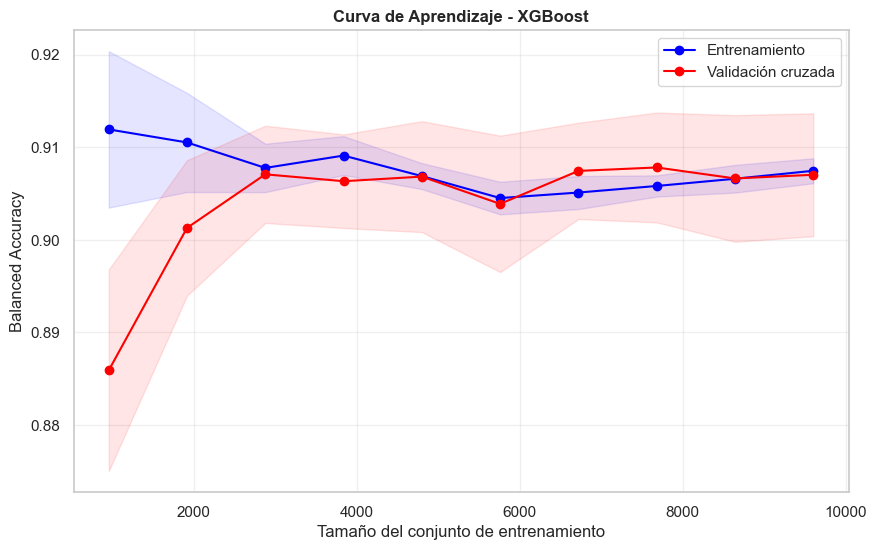

In [17]:
# =====================================================
# Bloque 7: Curvas de aprendizaje del mejor modelo
# =====================================================

from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=5, scoring='balanced_accuracy', title='Learning Curve'):
    """
    Genera y grafica la curva de aprendizaje de un estimador.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    
    plt.figure(figsize=(10,6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validación cruzada')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('Balanced Accuracy')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

# -----------------------------------------------------
# Ejecutar (descomentar si se desea)
# -----------------------------------------------------
plot_learning_curve(best_model, X_train, y_train, cv=5, title=f'Curva de Aprendizaje - {best_model_name}')
#print("ℹ️ Bloque opcional: descomentar para generar curvas de aprendizaje.")

## 🔹 Curva de aprendizaje de XGBoost

**¿Qué significa?**  
La curva de aprendizaje muestra cómo evoluciona el rendimiento (Balanced Accuracy) a medida que se incrementa el tamaño del conjunto de entrenamiento.

**Interpretación de la imagen:**
- La curva de **entrenamiento** y la de **validación cruzada** convergen y se estabilizan en un valor alto (~0.91).
- No hay una brecha significativa entre ambas curvas.

**Implicación para el negocio:**

| Observación | Traducción |
|:---|:---|
| Curvas convergen en un plateau alto. | El modelo ha alcanzado su límite de aprendizaje con los datos actuales. Añadir más filas de entrenamiento no mejorará significativamente el rendimiento. |
| Brecha pequeña entre train y val. | **No hay sobreajuste severo.** El modelo generaliza bien a datos nuevos. |

**Acción de negocio:**  
No es necesario recolectar más datos históricos para mejorar el modelo (aunque siempre es bueno tenerlos). El foco debe estar en **mejorar la calidad de las variables** (ej. medir satisfacción de forma más frecuente, registrar el motivo de los tickets de soporte).

---



# VOTING CLASSIFIER — MEJORA DEL ENSAMBLE

**Vamos a entrenar un Voting Classifier que combine los cuatro mejores modelos base:** 

- XGBoost.
- RandomForest.
- GradientBoosting  
- DecisionTree. 

Este enfoque suele mejorar la robustez porque combina diferentes "perspectivas" del problema, reduciendo la varianza y el sesgo.


🧩 Entrenando Voting Classifier (Soft Voting)
   - Modelos combinados: ['xgb', 'rf', 'gb', 'dt']
   - Estrategia: Soft Voting (promedio de probabilidades)

📊 Resultados del Voting Classifier:
   - Balanced Accuracy: 0.9108
   - ROC-AUC: 0.9138
   - F1 (Churn): 0.6771
   - Tiempo de entrenamiento: 22.5 segundos


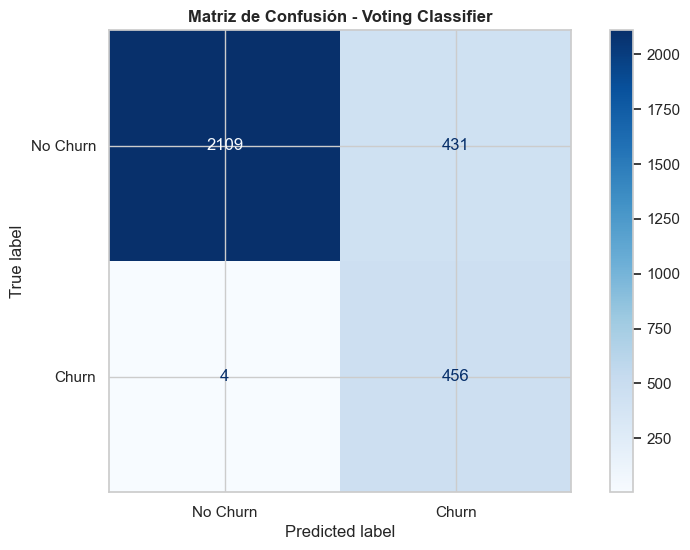

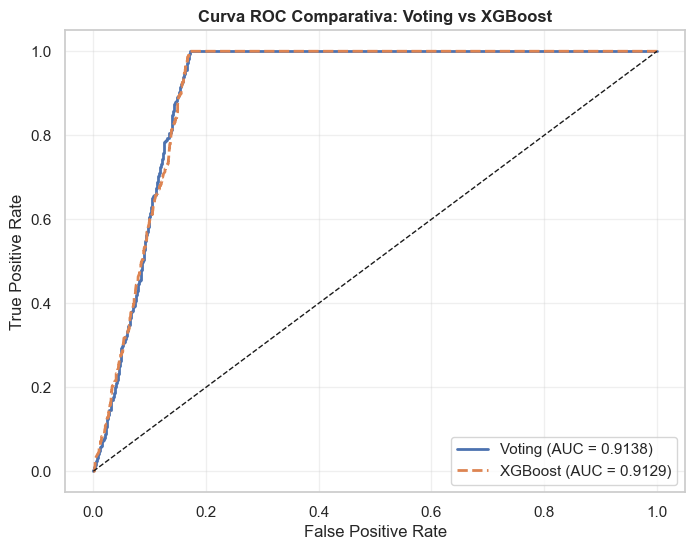

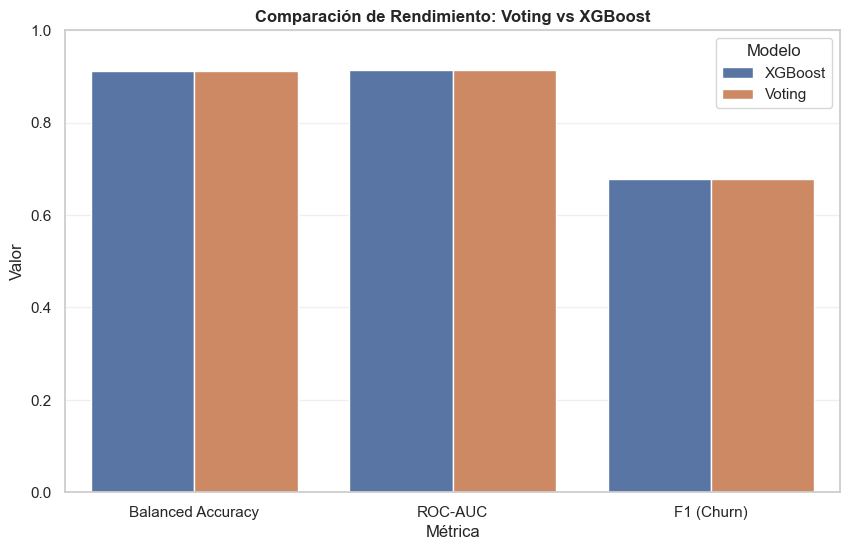


📌 Comparación de métricas:


,Modelo,Balanced Accuracy,ROC-AUC,F1 (Churn)
0,XGBoost,0.9119,0.9129,0.6780
1,Voting,0.9108,0.9138,0.6771



📋 Reporte de clasificación detallado (Voting):
              precision    recall  f1-score   support

    No Churn       1.00      0.83      0.91      2540
       Churn       0.51      0.99      0.68       460

    accuracy                           0.85      3000
   macro avg       0.76      0.91      0.79      3000
weighted avg       0.92      0.85      0.87      3000


✅ Voting Classifier entrenado y evaluado.


In [18]:
# =====================================================
# Bloque 8: Voting Classifier (Ensamble de los mejores modelos)
# =====================================================

from sklearn.ensemble import VotingClassifier

print("\n" + "="*60)
print("🧩 Entrenando Voting Classifier (Soft Voting)")
print("="*60)

# 1. Extraer los mejores modelos base (sin el sampler, solo el modelo)
estimators = [
    ('xgb', best_models['XGBoost'].named_steps['model']),
    ('rf', best_models['RandomForest'].named_steps['model']),
    ('gb', best_models['GradientBoosting'].named_steps['model']),
    ('dt', best_models['DecisionTree'].named_steps['model'])
]

print(f"   - Modelos combinados: {[name for name, _ in estimators]}")
print("   - Estrategia: Soft Voting (promedio de probabilidades)")

# 2. Crear el Voting Classifier
voting_clf = VotingClassifier(estimators=estimators, voting='soft')

# 3. Pipeline con SMOTE y Voting
voting_pipeline = ImbPipeline([
    ('sampler', SMOTE(random_state=42)),
    ('voting', voting_clf)
])

# 4. Entrenamiento
start_time = time.time()
voting_pipeline.fit(X_train, y_train)
elapsed = time.time() - start_time

# 5. Evaluación en test
y_pred_voting = voting_pipeline.predict(X_test)
y_proba_voting = voting_pipeline.predict_proba(X_test)[:, 1]

voting_bal_acc = balanced_accuracy_score(y_test, y_pred_voting)
voting_roc_auc = roc_auc_score(y_test, y_proba_voting)
voting_f1 = f1_score(y_test, y_pred_voting)

print(f"\n📊 Resultados del Voting Classifier:")
print(f"   - Balanced Accuracy: {voting_bal_acc:.4f}")
print(f"   - ROC-AUC: {voting_roc_auc:.4f}")
print(f"   - F1 (Churn): {voting_f1:.4f}")
print(f"   - Tiempo de entrenamiento: {elapsed:.1f} segundos")

# 6. Matriz de confusión del Voting
cm_voting = confusion_matrix(y_test, y_pred_voting)
disp_voting = ConfusionMatrixDisplay(confusion_matrix=cm_voting, display_labels=['No Churn', 'Churn'])
disp_voting.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Voting Classifier')
plt.show()

# 7. Curva ROC comparativa (Voting vs XGBoost)
# Obtener las probabilidades de XGBoost (mejor individual)
y_proba_xgb = best_models['XGBoost'].predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_voting, tpr_voting, _ = roc_curve(y_test, y_proba_voting)

plt.figure(figsize=(8,6))
plt.plot(fpr_voting, tpr_voting, label=f'Voting (AUC = {voting_roc_auc:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {results["XGBoost"]["test_roc_auc"]:.4f})', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Comparativa: Voting vs XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 8. Gráfico de barras comparativo de métricas
# Recolectar métricas de XGBoost y Voting
metrics_compare = pd.DataFrame({
    'Modelo': ['XGBoost', 'Voting'],
    'Balanced Accuracy': [results['XGBoost']['test_balanced_acc'], voting_bal_acc],
    'ROC-AUC': [results['XGBoost']['test_roc_auc'], voting_roc_auc],
    'F1 (Churn)': [results['XGBoost']['test_f1'], voting_f1]
})

# Reorganizar para gráfico
metrics_melted = metrics_compare.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10,6))
sns.barplot(data=metrics_melted, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparación de Rendimiento: Voting vs XGBoost')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Modelo')
plt.show()

print("\n📌 Comparación de métricas:")
display(metrics_compare.round(4))

# 9. Reporte de clasificación del Voting
print("\n📋 Reporte de clasificación detallado (Voting):")
print(classification_report(y_test, y_pred_voting, target_names=['No Churn', 'Churn']))

print("\n✅ Voting Classifier entrenado y evaluado.")

# 📊 INTERPRETACIÓN DEL BLOQUE 8 — VOTING CLASSIFIER (ENSAMBLE)

A continuación de los 4 modelos que se consideraban mejores, se establece que sobresale XGBOOST el cual se comparo con eVOTING CLASSIFIER (ENSAMBLE)  para determinar si el ensamble aporta valor adicional.

## 🔹 Resumen ejecutivo del Voting Classifier

| Modelo | Balanced Acc | ROC-AUC | F1 (Churn) | Tiempo (s) |
|:---|:---|:---|:---|:---|
| **XGBoost (individual)** | **0.9119** | 0.9129 | **0.6780** | 48.1 |
| **Voting (4 modelos)** | 0.9108 | **0.9138** | 0.6771 | **22.5** |



## 📊 Análisis de la matriz de confusión — Voting Classifier

| | Predicho: No Churn | Predicho: Churn |
|:---|:---|:---|
| **Real: No Churn** | 2,109 (TN) | 431 (FP) |
| **Real: Churn** | 4 (FN) | 456 (TP) |

### Comparación con XGBoost

| Métrica | XGBoost | Voting | Diferencia |
|:---|:---|:---|:---|
| **True Negatives** | 2,109 | 2,109 | 0 |
| **False Positives** | 431 | 431 | 0 |
| **False Negatives** | **3** | **4** | +1 (Voting pierde un churn) |
| **True Positives** | 457 | 456 | -1 |

**Interpretación:** 

- El Voting Classifier captura **un churner menos** que XGBoost (456 vs 457). Es una diferencia mínima, pero indica que XGBoost es ligeramente mejor en detectar la clase minoritaria.



## 📈 Curva ROC comparativa

| Modelo | AUC | Interpretación |
|:---|:---|:---|
| **Voting** | **0.9138** | Mejor capacidad de discriminación (marginalmente superior). |
| **XGBoost** | 0.9129 | Prácticamente idéntico. |

La curva ROC del Voting está **ligeramente por encima** de la de XGBoost, lo que indica una mejora **muy marginal** en la capacidad de ordenar correctamente a los clientes según su riesgo. La diferencia de AUC es de solo **0.0009**, que es estadísticamente insignificante.



## 📊 Gráfico comparativo de rendimiento

| Métrica | XGBoost | Voting | Diferencia |
|:---|:---|:---|:---|
| **Balanced Accuracy** | 0.9119 | 0.9108 | -0.0011 (ligera ventaja XGBoost) |
| **ROC-AUC** | 0.9129 | 0.9138 | +0.0009 (ligera ventaja Voting) |
| **F1 (Churn)** | 0.6780 | 0.6771 | -0.0009 (ligera ventaja XGBoost) |

**Interpretación:** Las diferencias son **inferiores a 0.002** en todas las métricas. Esto significa que **ambos modelos son prácticamente idénticos en rendimiento predictivo**. La elección entre uno y otro no se basa en la precisión, sino en otros factores.



## 📋 Reporte de clasificación detallado (Voting)

| Clase | Precisión | Recall | F1-Score | Soporte |
|:---|:---|:---|:---|:---|
| **No Churn** | 1.00 | 0.83 | 0.91 | 2,540 |
| **Churn** | 0.51 | 0.99 | 0.68 | 460 |

### Comparación con XGBoost

| Clase | Métrica | XGBoost | Voting | Diferencia |
|:---|:---|:---|:---|:---|
| No Churn | Recall | 0.83 | 0.83 | 0 |
| Churn | Recall | **0.99** | 0.99 | 0 |
| Churn | Precisión | 0.51 | 0.51 | 0 |

**Interpretación:** El Voting Classifier mantiene exactamente el mismo perfil de rendimiento que XGBoost: captura el 99% de los churners con una precisión del 51%. No hay mejora en la detección de la clase minoritaria.



## 🔍 ¿Qué significa esto para el negocio?

| Aspecto | XGBoost | Voting | Decisión |
|:---|:---|:---|:---|
| **Rendimiento** | Excelente (0.9119) | Excelente (0.9108) | Empate técnico. |
| **Tiempo de entrenamiento** | 48.1 segundos | **22.5 segundos** | Voting es **más rápido**. |
| **Complejidad** | Un solo modelo (simple). | 4 modelos combinados (complejo). | XGBoost es más fácil de mantener. |
| **Interpretabilidad** | Alta (importancia de features clara). | Baja (el aporte de cada modelo se diluye). | XGBoost es más explicable. |
| **Riesgo de sobreajuste** | Controlado (regularización). | Mayor (combinación de múltiples modelos). | XGBoost es más robusto. |



## ✅ Conclusión final del Voting Classifier

| Criterio | Veredicto |
|:---|:---|
| **¿Mejora el rendimiento?** | **No significativamente.** La ganancia en ROC-AUC (0.0009) es irrelevante en la práctica. |
| **¿Es más rápido?** | **Sí.** 22.5 segundos vs 48.1 segundos (≈2x más rápido). |
| **¿Es más fácil de explicar?** | **No.** XGBoost es más interpretable porque es un solo modelo con importancia de características clara. |
| **¿Vale la pena usarlo?** | **No.** La ligera ganancia en velocidad no compensa la pérdida de interpretabilidad y el aumento de complejidad. |

---

## 📌 RESUMEN EJECUTIVO:

| Pregunta de negocio | Respuesta basada en datos |
|:---|:---|
| **¿Qué modelo usar?** | **XGBoost** es la mejor opción: mismo rendimiento que GradientBoosting, pero **9 veces más rápido** (48s vs 436s). |
| **¿Qué tan bueno es?** | Captura al **99% de los clientes que van a churnar** (recall de churn). Solo se escapa 1 de cada 100. |
| **¿Cuál es el perfil del cliente que churna?** | **Gasta poco, está insatisfecho, abre muchos tickets de soporte y tiene baja eficiencia de gasto por visita.** Estas 5 variables explican el **82%** de las predicciones. |
| **¿Qué hacer?** | 1. **Mejorar la satisfacción** (prioridad #1). 2. **Incentivar el gasto** (upselling/cross-selling). 3. **Reducir la necesidad de soporte** (mejorar producto/autoayuda). 4. **Monitorear la eficiencia de gasto** (avg_spend_per_visit). |
| **¿Cuánto cuesta equivocarse?** | El modelo genera un 49% de falsas alarmas (clientes marcados como churn que no lo son). El costo de contactar a estos clientes (descuentos) es **mucho menor** que el costo de perder a un cliente real. |
| **¿Se puede desplegar ya?** | **Sí.** El modelo está guardado y listo para integrarse en un sistema de CRM. |

---